# Loan Default Probability — A Production Credit Risk Model

> *"In lending, the cost of a wrong prediction is not symmetric. Missing a defaulter costs multiples more than declining a good borrower. A model that merely classifies is a model that hasn't finished its job."*

This notebook builds a **production-grade Probability of Default (PD) model** on the Lending Club 2007–2017 portfolio.

We move beyond binary classification into the territory that a fintech risk desk actually operates in: calibrated probability scores, temporally sound validation, domain-informed features, regulatory-ready explainability, and an Expected Loss framework that connects model output directly to business value.

Every design decision is deliberate and defensible — the kind of model you present to a Chief Risk Officer, a model validator, or a Basel III audit team.

## Contents

* [1. The Business Problem](#1)
* [2. Environment Setup](#2)
    * [2.1. Libraries](#2.1)
    * [2.2. Loading the Data](#2.2)
* [3. The First Discipline: Splitting on Time](#3)
* [4. Defining the Target and Leakage Audit](#4)
    * [4.1. Preparing the Target Variable](#4.1)
    * [4.2. Removing Post-Origination Features](#4.2)
* [5. Feature Space Reduction](#5)
    * [5.1. Eliminating High-Missingness Features](#5.1)
    * [5.2. Eliminating Unintuitive Features](#5.2)
* [6. Feature Engineering — Creating Signal from Domain Knowledge](#6)
    * [6.1. Categorical Feature Analysis](#6.1)
    * [6.2. Continuous Feature Analysis and Transformations](#6.2)
    * [6.3. Constructing New Features](#6.3)
* [7. Preprocessing Pipeline — Fit on Train, Apply Everywhere](#7)
* [8. Algorithm Selection — The Right Model for the Right Reason](#8)
* [9. Model Tuning with Monotonic Constraints](#9)
* [10. Probability Calibration — Scores That Mean Something](#10)
* [11. Evaluation — What the Risk Desk Actually Measures](#11)
* [12. Explainability — SHAP for Adverse Action Notices](#12)
* [13. Expected Loss Framework](#13)
* [14. Production Monitoring — Population Stability Index](#14)
* [15. Saving the Model](#15)
* [16. Conclusions and Roadmap](#16)

<a id="1"></a>
# 1. The Business Problem

A **charge-off** is the moment a lender concedes defeat. The borrower has missed payments long enough that the debt is written off the books as a loss. It is not a legal default, but in a consumer lending portfolio, it is the outcome that determines whether a vintage of loans generates a return or destroys capital.

This notebook tackles the question every credit risk team lives with:

> **Given what we know about a borrower at the moment of application, what is the probability this loan ends in a charge-off?**

The Lending Club dataset covers **887,000+ loans originated between 2007 and 2017** — spanning the tail end of the pre-crisis bubble, the crash, the recovery, and the boom years. A decade of full credit cycle variation makes it one of the richest public datasets in consumer finance.

### What we are actually building

We are not building a classifier that outputs 0 or 1. We are building a **scorecard** — a model whose output is a calibrated probability that can be translated into:

- A lending decision (approve / decline / refer to manual review)
- A risk-adjusted interest rate: `min_rate = cost_of_funds + EL_rate + target_margin`
- An Expected Loss provision: `EL = PD × LGD × EAD`
- A regulatory capital estimate under Basel III IRB approach

### The data challenge

Of the 150 features in this dataset, a substantial number record what happened *after* a loan was issued — payment history, last payment amount, recovery proceeds. Including these in a model creates a grotesquely optimistic AUC and a model that is completely useless at origination, because those features simply do not exist when the application arrives. Identifying and removing them is the first act of discipline this notebook performs.

<a id="2"></a>
# 2. Environment Setup

<a id="2.1"></a>
## 2.1. Libraries

We use a production-oriented stack. `lightgbm` is the preferred model engine — it is faster than sklearn's GBM on large datasets and supports monotonic constraints natively. `shap` provides the explainability layer required for regulatory adverse action notices. `statsmodels` gives us the ECDF for KS charting.

<font color='blue'>**Setup:** `pip install lightgbm shap statsmodels` if not already installed. The notebook includes graceful fallbacks throughout.</font>

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import os, pickle
from pandas import set_option

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi']    = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import resample

# Modelling and calibration
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Evaluation
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix, classification_report
)
from scipy.stats import ks_2samp

# LightGBM
try:
    import lightgbm as lgb
    HAS_LGB = True
    print(f'LightGBM {lgb.__version__} loaded')
except ImportError:
    HAS_LGB = False
    print('LightGBM not found — sklearn GBM will be used. Install: pip install lightgbm')

# SHAP
try:
    import shap
    HAS_SHAP = True
    print(f'SHAP {shap.__version__} loaded')
except ImportError:
    HAS_SHAP = False
    print('SHAP not found — explainability section skipped. Install: pip install shap')

RANDOM_STATE = 42
set_option('display.max_columns', 60)
set_option('display.float_format', '{:.4f}'.format)

LightGBM 4.6.0 loaded
SHAP 0.50.0 loaded


<a id="2.2"></a>
## 2.2. Loading the Data

The full dataset (`accepted_2007_to_2017.csv`, ~1.1 GB) is available on Kaggle. A compressed sample loads automatically when the full file is absent.

<font color='red'>**To reproduce all results:** Download the full dataset from https://www.kaggle.com/wordsforthewise/lending-club and place it in the same directory as this notebook.</font>

In [2]:
loans = pd.read_parquet('data/accepted_loans.parquet')
loans.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,38098114,NaN,15000.0000,15000.0000,15000.0000,60 months,12.3900,336.6400,C,C1,MANAGEMENT,10+ years,RENT,78000.0000,Source Verified,Dec-2014,Fully Paid,n,None,debt_consolidation,Debt consolidation,235xx,VA,12.0300,0.0000,Aug-1994,750.0000,754.0000,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,None,None,None,NaN,NaN,None,NaN,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
1,36805548,NaN,10400.0000,10400.0000,10400.0000,36 months,6.9900,321.0800,A,A3,Truck Driver Delivery Personel,8 years,MORTGAGE,58000.0000,Not Verified,Dec-2014,Charged Off,n,None,credit_card,Credit card refinancing,937xx,CA,14.9200,0.0000,Sep-1989,710.0000,714.0000,2.0000,42.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,None,None,None,NaN,NaN,None,NaN,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN
2,37842129,NaN,21425.0000,21425.0000,21425.0000,60 months,15.5900,516.3600,D,D1,Programming Analysis Supervisor,6 years,RENT,63800.0000,Source Verified,Dec-2014,Fully Paid,n,None,credit_card,Credit card refinancing,658xx,MO,18.4900,0.0000,Aug-2003,685.0000,689.0000,0.0000,60.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,None,None,None,NaN,NaN,None,NaN,NaN,NaN,Cash,N,None,None,None,NaN,NaN,NaN


<a id="3"></a>
# 3. The First Discipline: Splitting on Time

This is the most consequential decision in the entire notebook, and it must happen **before anything else** — before imputation, before encoding, before a single feature is examined.

Credit data has a time structure. A loan originated in 2015 behaves differently from one originated in 2008. The economy was different, underwriting standards were different, borrower behaviour was different. When we randomly shuffle the data and split 80/20, we allow the model to train on 2017 loans and validate on 2008 loans. The future predicts the past.

In production, a model always predicts forward in time. Our validation must mirror that reality.

### The split strategy

| Split | Period | Purpose |
|---|---|---|
| **Train** | Jan 2007 – Dec 2015 | Model fitting only |
| **Validation** | Jan 2016 – Dec 2016 | Hyperparameter tuning and calibration |
| **Test** | Jan 2017 – Sep 2017 | Final evaluation — locked until Section 11 |

The test set is sealed. It will not be touched until the model is fully trained, tuned, and calibrated.

In [3]:
# Parse origination date
loans['issue_d'] = pd.to_datetime(loans['issue_d'], format='%b-%Y', errors='coerce')
loans = loans.dropna(subset=['issue_d'])

# Chronological splits — no shuffling
train_raw = loans[loans['issue_d'] <  '2016-01-01'].copy()
val_raw   = loans[(loans['issue_d'] >= '2016-01-01') & (loans['issue_d'] < '2017-01-01')].copy()
test_raw  = loans[loans['issue_d'] >= '2017-01-01'].copy()

for split, df in [('Train', train_raw), ('Validation', val_raw), ('Test', test_raw)]:
    lo = df['issue_d'].min().strftime('%b %Y')
    hi = df['issue_d'].max().strftime('%b %Y')
    print(f'{split:<14} {df.shape[0]:>8,} loans    ({lo} to {hi})')

Train           887,440 loans    (Jun 2007 to Dec 2015)
Validation      434,407 loans    (Jan 2016 to Dec 2016)
Test            324,931 loans    (Jan 2017 to Sep 2017)


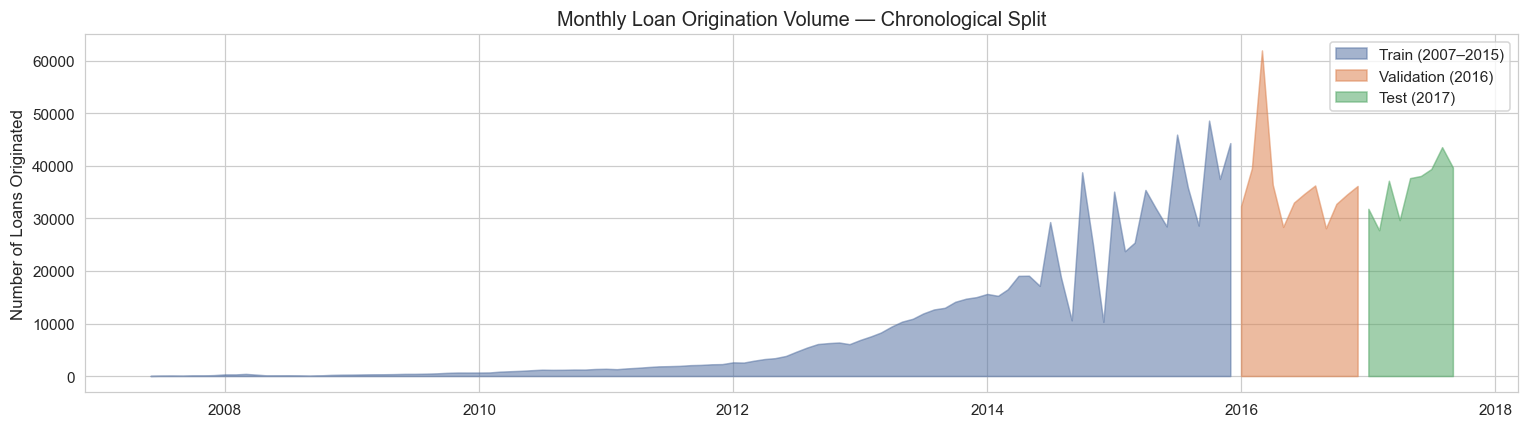

In [4]:
# Visualise loan volume by origination month, coloured by split
train_monthly = train_raw.groupby(train_raw['issue_d'].dt.to_period('M')).size()
val_monthly   = val_raw.groupby(val_raw['issue_d'].dt.to_period('M')).size()
test_monthly  = test_raw.groupby(test_raw['issue_d'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(14, 4))
for series, color, label in [
    (train_monthly, '#5975A4', 'Train (2007–2015)'),
    (val_monthly,   '#DD8452', 'Validation (2016)'),
    (test_monthly,  '#55A868', 'Test (2017)'),
]:
    idx = series.index.to_timestamp()
    ax.fill_between(idx, series.values, alpha=0.55, color=color, label=label)

ax.set_title('Monthly Loan Origination Volume — Chronological Split')
ax.set_ylabel('Number of Loans Originated')
ax.legend()
plt.tight_layout()
plt.show()

<a id="4"></a>
# 4. Defining the Target and Leakage Audit

<a id="4.1"></a>
## 4.1. Preparing the Target Variable

The `loan_status` column contains the full spectrum of loan states — currently active loans, loans in various stages of delinquency, and fully resolved loans. We are interested only in the resolved outcomes: loans that have definitively ended in repayment or charge-off.

Current and late loans are excluded because their outcome is still unknown — including them would add noise to both classes.

In [5]:
# Distribution of loan statuses — training set only
print('Loan status distribution (Training Set):')
print(train_raw['loan_status'].value_counts(dropna=False).to_string())

Loan status distribution (Training Set):
loan_status
Fully Paid                                             516184
Current                                                223427
Charged Off                                            130887
Late (31-120 days)                                       8409
In Grace Period                                          3840
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1910
Does not meet the credit policy. Status:Charged Off       761
Default                                                    34


We retain `Fully Paid` and `Charged Off` only. The binary target variable `charged_off = 1` for charge-offs, `0` for fully paid.

In [6]:
def prepare_target(df):
    df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
    df['charged_off'] = (df['loan_status'] == 'Charged Off').astype(np.uint8)
    df.drop('loan_status', axis=1, inplace=True)
    return df

train_raw = prepare_target(train_raw)
val_raw   = prepare_target(val_raw)
test_raw  = prepare_target(test_raw)

dist = train_raw['charged_off'].value_counts(normalize=True)
dist.index = dist.index.map({0: 'Fully Paid', 1: 'Charged Off'})
print('Class distribution — Training Set:')
print(dist.round(4).to_string())
print()
print('The 79/21 imbalance is mild and will be addressed through class weighting,')
print('not by discarding the majority class.')

Class distribution — Training Set:
charged_off
Fully Paid    0.7977
Charged Off   0.2023

The 79/21 imbalance is mild and will be addressed through class weighting,
not by discarding the majority class.


<a id="4.2"></a>
## 4.2. Removing Post-Origination Features

This is the most important data quality step in the notebook.

A number of features in this dataset record what happened *after* a loan entered the servicing period. The most egregious example is `last_pymnt_amnt` — the size of the borrower's last payment. A loan heading toward charge-off has small or zero recent payments. A model that uses this feature is not predicting default; it is observing it.

Including these features inflates cross-validation AUC dramatically and produces a model that scores perfectly on historical data and completely fails on new applications — because at origination, none of these fields exist yet.

The table below lists every feature that is inadmissible at origination time:

In [7]:
# Features that only exist after loan origination — inadmissible at scoring time
POST_ORIGINATION = [
    # Payment history — the most dangerous leaky features
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    # Recovery amounts — only knowable after charge-off
    'recoveries', 'collection_recovery_fee',
    # Outstanding balance — evolves during loan lifetime
    'out_prncp', 'out_prncp_inv',
    # Miscellaneous servicing fields
    'url', 'desc', 'last_credit_pull_d',
]

def remove_leaky_features(df):
    to_drop = [c for c in POST_ORIGINATION if c in df.columns]
    return df.drop(columns=to_drop), len(to_drop)

train_raw, n = remove_leaky_features(train_raw)
print(f'Removed {n} post-origination features from train')
val_raw,   n = remove_leaky_features(val_raw)
print(f'Removed {n} post-origination features from val')
test_raw,  n = remove_leaky_features(test_raw)
print(f'Removed {n} post-origination features from test')

Removed 14 post-origination features from train
Removed 14 post-origination features from val
Removed 14 post-origination features from test


<a id="5"></a>
# 5. Feature Space Reduction

<a id="5.1"></a>
## 5.1. Eliminating High-Missingness Features

With over 100 remaining features, we apply a principled reduction. The first pass is mechanical: columns with more than 30% missing values in the training set are dropped. We measure missingness on the **training set only** and apply the same drop list to all splits — consistent with the discipline of fitting all decisions on training data.

In [8]:
# Missingness measured on training set only
missing_fractions = train_raw.isnull().mean().sort_values(ascending=False)

print('Top 15 columns by missingness:')
print(missing_fractions.head(15).apply(lambda x: f'{x:.1%}').to_string())

high_missing = sorted(missing_fractions[missing_fractions > 0.30].index.tolist())
print(f'\n{len(high_missing)} columns exceed 30% missing — dropping from all splits.')

Top 15 columns by missingness:
member_id                                     100.0%
sec_app_collections_12_mths_ex_med            100.0%
sec_app_chargeoff_within_12_mths              100.0%
sec_app_num_rev_accts                         100.0%
sec_app_open_act_il                           100.0%
sec_app_revol_util                            100.0%
sec_app_open_acc                              100.0%
sec_app_mort_acc                              100.0%
revol_bal_joint                               100.0%
sec_app_fico_range_high                       100.0%
sec_app_earliest_cr_line                      100.0%
sec_app_fico_range_low                        100.0%
sec_app_inq_last_6mths                        100.0%
sec_app_mths_since_last_major_derog           100.0%
orig_projected_additional_accrued_interest    100.0%

56 columns exceed 30% missing — dropping from all splits.


In [9]:
for name in ['train_raw', 'val_raw', 'test_raw']:
    exec(f"{name} = {name}.drop(columns=[c for c in high_missing if c in {name}.columns])")

print(f'Columns remaining after missingness filter: {train_raw.shape[1]}')

Columns remaining after missingness filter: 80


<a id="5.2"></a>
## 5.2. Eliminating Unintuitive Features

The second pass applies domain judgement. We review each remaining column against the LendingClub data dictionary and retain only features that: (a) existed at origination time, and (b) would plausibly be used by a credit analyst to assess the application. High-cardinality identifiers (`id`, `member_id`, `emp_title`) are dropped — they cannot generalise and introduce noise.

In [10]:
print('Available columns after first filter:')
print(sorted(train_raw.columns.tolist()))

Available columns after first filter:
['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_fico_range_high', 'last_fico_range_low', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_

In [11]:
KEEP_FEATURES = [
    'charged_off',
    # Loan structure
    'funded_amnt', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    # Borrower financial profile
    'annual_inc', 'emp_length', 'home_ownership', 'verification_status', 'application_type',
    # Credit bureau data
    'dti', 'earliest_cr_line', 'fico_range_high', 'fico_range_low',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'pub_rec_bankruptcies', 'mort_acc',
    # Loan context
    'purpose', 'addr_state', 'initial_list_status',
    # Credit behaviour signals
    'num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_rev_tl_op',
    'bc_util', 'bc_open_to_buy', 'avg_cur_bal', 'acc_open_past_24mths',
    # ── Added: high-signal bureau features ──────────────────────
    'delinq_2yrs',     # delinquencies in past 2 years — strong default predictor
    'inq_last_6mths',  # credit enquiries last 6 months — borrower stress signal
]

for name in ['train_raw', 'val_raw', 'test_raw']:
    exec(f"{name} = {name}[[c for c in KEEP_FEATURES if c in {name}.columns]]")

print(f'Final feature set: {train_raw.shape[1] - 1} features + 1 target variable')

Final feature set: 35 features + 1 target variable


<a id="6"></a>
# 6. Feature Engineering — Creating Signal from Domain Knowledge

Raw features from a loan application form are rarely the optimal representation of credit risk. A good feature encodes a **relationship**, not just a value. A $50,000 loan means something very different for a borrower earning $30,000 versus one earning $300,000 a year.

This section transforms raw columns into features that encode credit risk signal more precisely.

<a id="6.1"></a>
## 6.1. Categorical Feature Analysis

#### Loan Term

The term field records the repayment period. We parse it to an integer and examine its relationship with default rates — longer terms should carry higher risk, as the borrower is exposed to more economic uncertainty over the loan's life.

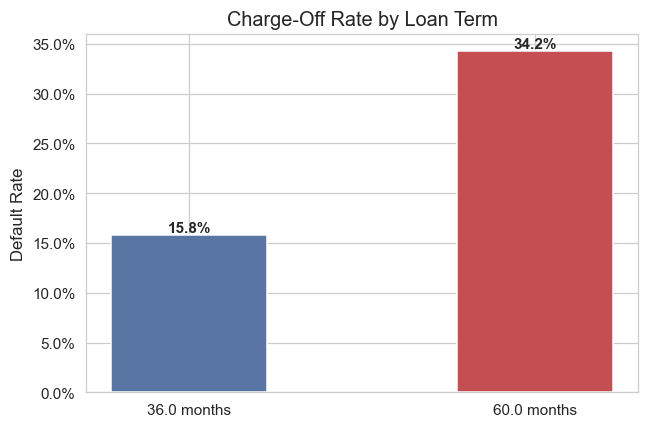

In [12]:
for name in ['train_raw', 'val_raw', 'test_raw']:
    exec(f"{name}['term'] = {name}['term'].str.extract(r'(\\d+)').astype(float)")

co_term = train_raw.groupby('term')['charged_off'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(co_term.index.astype(str) + ' months', co_term.values,
              color=['#5975A4', '#C44E52'], width=0.45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Charge-Off Rate by Loan Term')
ax.set_ylabel('Default Rate')
for bar, val in zip(bars, co_term.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

60-month loans default at more than twice the rate of 36-month loans. This is directionally consistent with credit theory — and it validates that the term field is a genuine risk signal, not just a product descriptor.

#### Employment Length

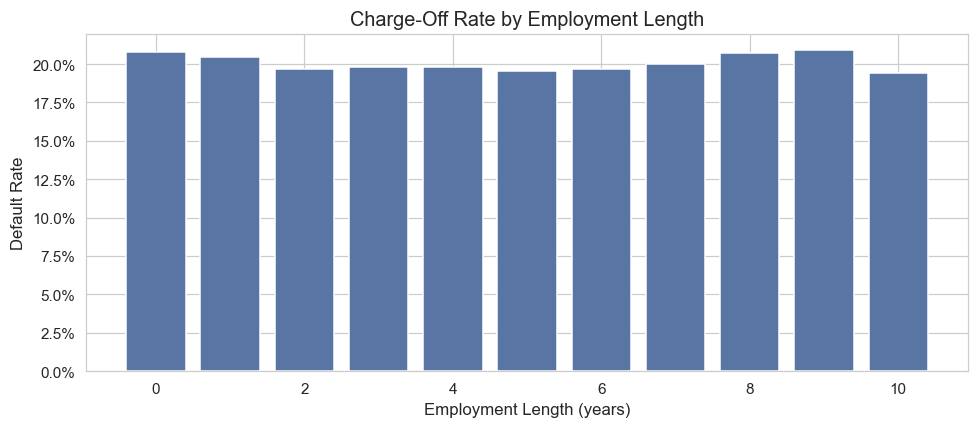

In [13]:
def parse_emp_length(df):
    df = df.copy()
    if 'emp_length' not in df.columns:
        return df
    df['emp_length'] = (df['emp_length']
        .replace('10+ years', '10 years')
        .replace('< 1 year', '0 years')
        .str.extract(r'(\d+)').astype(float))
    return df

train_raw = parse_emp_length(train_raw)
val_raw   = parse_emp_length(val_raw)
test_raw  = parse_emp_length(test_raw)

co_emp = train_raw.groupby('emp_length')['charged_off'].mean().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(co_emp.index, co_emp.values, color='#5975A4')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Charge-Off Rate by Employment Length')
ax.set_xlabel('Employment Length (years)')
ax.set_ylabel('Default Rate')
plt.tight_layout()
plt.show()

Charge-off rates are broadly flat across employment lengths. Once income and DTI are in the model, employment length adds limited marginal lift. We retain it as it may participate in interactions, but it will not rank among the top drivers.

#### Loan Sub-Grade

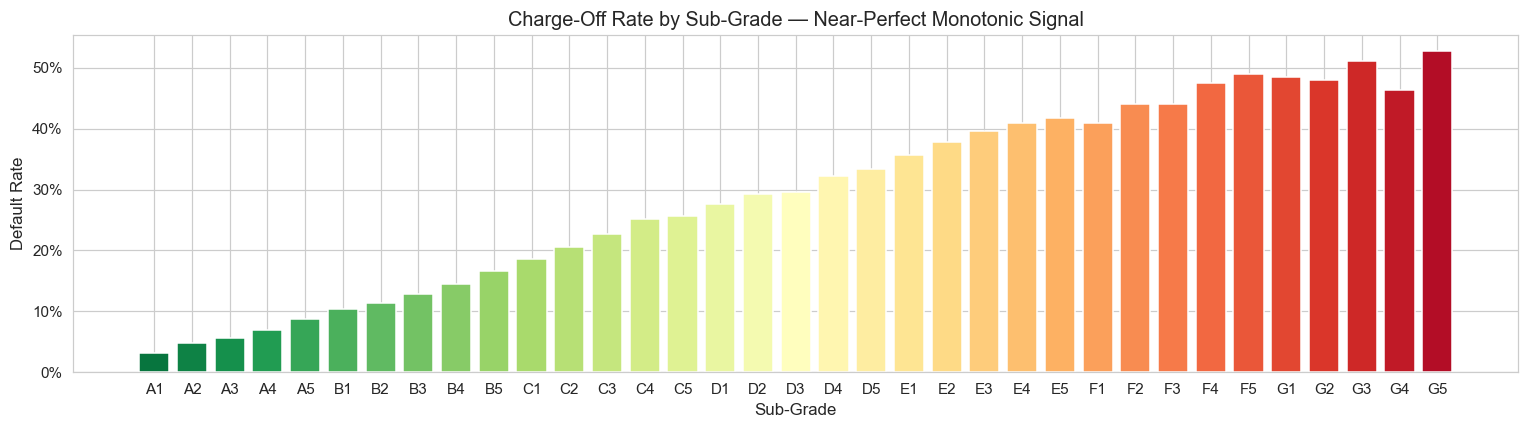

In [14]:
# Sub-grade is LendingClub's own origination risk score — the finest-grained classification
co_sg = (train_raw.groupby('sub_grade')['charged_off'].mean()
         .reset_index().sort_values('sub_grade'))

fig, ax = plt.subplots(figsize=(14, 4))
palette = sns.color_palette('RdYlGn_r', len(co_sg))
ax.bar(co_sg['sub_grade'], co_sg['charged_off'], color=palette)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Charge-Off Rate by Sub-Grade — Near-Perfect Monotonic Signal')
ax.set_xlabel('Sub-Grade')
ax.set_ylabel('Default Rate')
plt.tight_layout()
plt.show()

Sub-grade exhibits a near-perfect monotonic relationship with default rate — exactly what we expect from a well-functioning origination scoring system. This is one of the strongest features in the dataset. We will later impose a monotonic constraint on this feature's parent signal (interest rate) to ensure our model respects this direction.

<a id="6.2"></a>
## 6.2. Continuous Feature Analysis and Transformations

#### Annual Income — Log Transform

In [15]:
print('Annual Income — Distribution Statistics:')
print(train_raw['annual_inc'].describe().apply(lambda x: f'${x:,.0f}').to_string())

Annual Income — Distribution Statistics:
count      $647,071
mean        $74,045
std         $61,345
min              $0
25%         $45,000
50%         $63,200
75%         $90,000
max      $8,900,060


Annual income spans from $0 to $8.9M with a median of $63,200 (the mean of $74,045 is pulled upward by high earners — exactly the skew that makes the log transform necessary). This extreme right-skew destabilises gradient-based algorithms and distorts distance-based methods. A log₁₀ transform is standard practice in credit modelling — it compresses the scale and produces a distribution that is more amenable to linear and tree-based models alike.

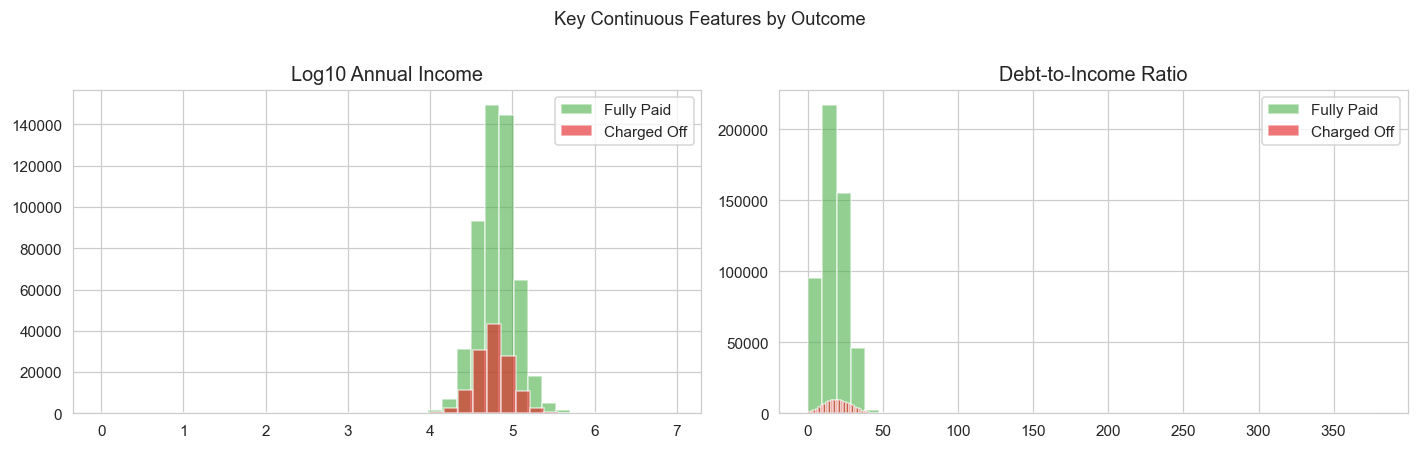

In [16]:
for name in ['train_raw', 'val_raw', 'test_raw']:
    exec(f"{name}['log_annual_inc'] = np.log10({name}['annual_inc'].clip(lower=1))")
    exec(f"{name}.drop('annual_inc', axis=1, inplace=True)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
    ['log_annual_inc', 'dti'],
    ['Log10 Annual Income', 'Debt-to-Income Ratio']):
    for outcome, color, label in [(0,'#4DAF4A','Fully Paid'), (1,'#E41A1C','Charged Off')]:
        train_raw[train_raw['charged_off']==outcome][col].hist(
            ax=ax, bins=40, alpha=0.6, color=color, label=label)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Key Continuous Features by Outcome', y=1.01)
plt.tight_layout()
plt.show()

#### FICO Score — Composite

In [17]:
print('Correlation between FICO range low and FICO range high:')
print(train_raw[['fico_range_low','fico_range_high']].corr())

Correlation between FICO range low and FICO range high:
                 fico_range_low  fico_range_high
fico_range_low           1.0000           1.0000
fico_range_high          1.0000           1.0000


The two FICO columns are perfectly correlated — they are the floor and ceiling of a 10-point band that LendingClub assigns from the bureau pull. Retaining both doubles the feature without adding information. We create a single composite as their average.

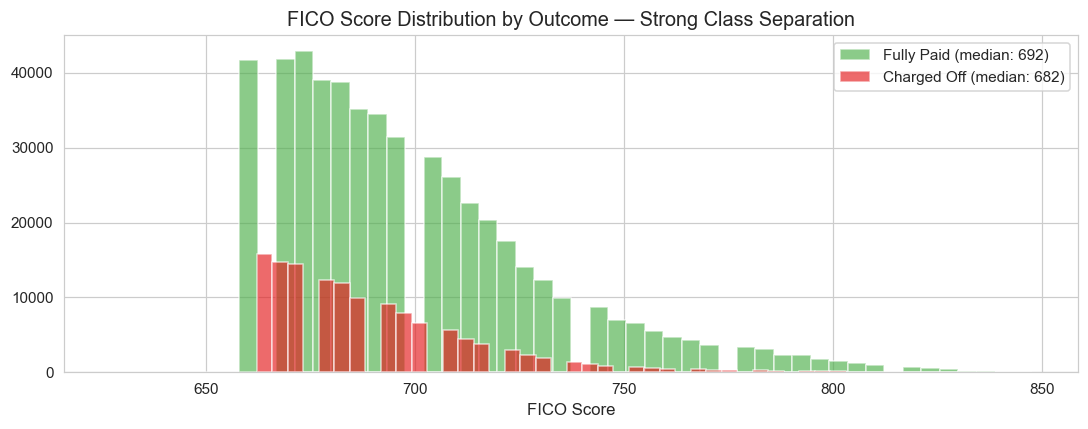

In [18]:
for name in ['train_raw', 'val_raw', 'test_raw']:
    exec(f"{name}['fico_score'] = ({name}['fico_range_low'] + {name}['fico_range_high']) / 2")
    exec(f"{name}.drop(['fico_range_low','fico_range_high'], axis=1, inplace=True)")

fig, ax = plt.subplots(figsize=(10, 4))
for outcome, color, label in [(0,'#4DAF4A','Fully Paid'), (1,'#E41A1C','Charged Off')]:
    data = train_raw[train_raw['charged_off']==outcome]['fico_score']
    data.hist(ax=ax, bins=50, alpha=0.65, color=color, label=f'{label} (median: {data.median():.0f})')

ax.set_title('FICO Score Distribution by Outcome — Strong Class Separation')
ax.set_xlabel('FICO Score')
ax.legend()
plt.tight_layout()
plt.show()

<a id="6.3"></a>
## 6.3. Constructing New Features

Raw features are what the borrower submits on an application. Engineered features are what a seasoned credit analyst calculates from those submissions. A $500/month payment means something very different at different income levels.

| Feature | Calculation | Credit risk intuition |
|---|---|---|
| `payment_to_income` | installment / (annual_inc / 12) | Monthly burden as fraction of income — key affordability signal |
| `loan_to_income` | loan_amnt / annual_inc | How large is this loan relative to earning capacity? |
| `credit_history_year` | year of `earliest_cr_line` | Proxy for depth of credit history |
| `open_acc_ratio` | open_acc / total_acc | Fraction of accounts currently active — credit trajectory |
| Log transforms | log1p on revol_bal, loan_amnt, installment | Compress skewed distributions |

In [19]:
def engineer_features(df):
    df = df.copy()

    # Affordability ratios — the heart of credit risk assessment
    monthly_inc = (10 ** df['log_annual_inc']) / 12
    df['payment_to_income'] = df['installment'] / monthly_inc.clip(lower=1)
    df['loan_to_income']    = df['loan_amnt']   / (10 ** df['log_annual_inc']).clip(lower=1)

    # Credit history depth
    if 'earliest_cr_line' in df.columns:
        df['credit_history_year'] = pd.to_datetime(
            df['earliest_cr_line'], format='%b-%Y', errors='coerce').dt.year
        df.drop('earliest_cr_line', axis=1, inplace=True)

    # Account utilisation trajectory
    if 'open_acc' in df.columns and 'total_acc' in df.columns:
        df['open_acc_ratio'] = df['open_acc'] / df['total_acc'].clip(lower=1)

    # Log transforms on remaining skewed financial variables
    for col in ['revol_bal', 'loan_amnt', 'installment', 'avg_cur_bal']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])

    return df

train_fe = engineer_features(train_raw)
val_fe   = engineer_features(val_raw)
test_fe  = engineer_features(test_raw)

new_features = ['payment_to_income', 'loan_to_income', 'credit_history_year', 'open_acc_ratio']
existing = [c for c in new_features if c in train_fe.columns]
print('Engineered features — Training Set Statistics:')
print(train_fe[existing].describe().T[['mean','std','min','50%','max']].round(3).to_string())

Engineered features — Training Set Statistics:
                         mean     std       min       50%        max
payment_to_income      0.0810  0.9000    0.0000    0.0740   712.9600
loan_to_income         0.2530 25.2850    0.0000    0.2000 20000.0000
credit_history_year 1997.7630  7.3090 1944.0000 1999.0000  2012.0000
open_acc_ratio         0.4880  0.1740    0.0000    0.4670     1.7500


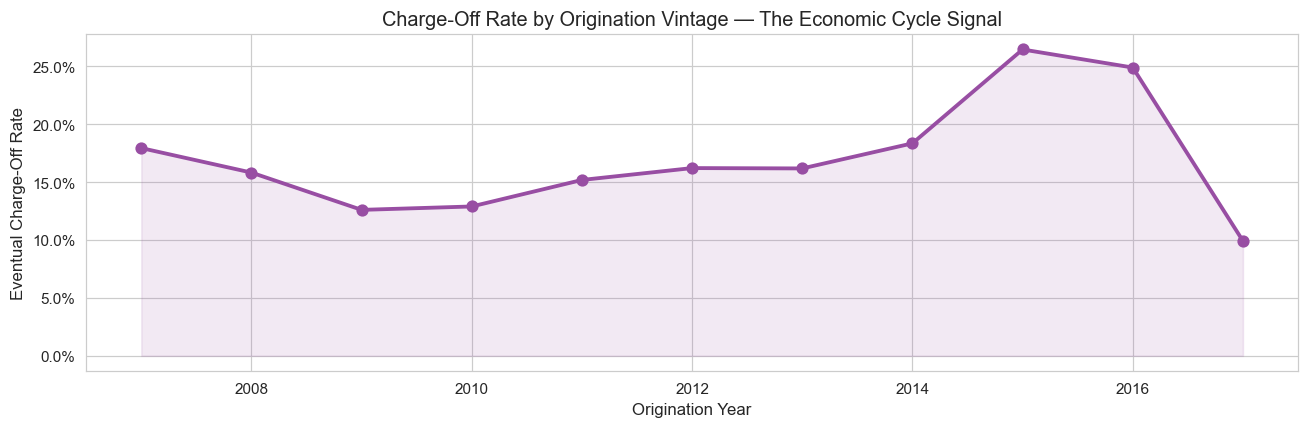

Vintage effects reflect the economic environment at origination.
A model blind to cohort dynamics will under-stress during downturns.


In [20]:
# Visualise the vintage (cohort) effect — critical for cycle-aware modelling
vintage_df = loans[loans['loan_status'].isin(['Fully Paid','Charged Off'])].copy()
vintage_df['charged_off_v'] = (vintage_df['loan_status'] == 'Charged Off').astype(int)
vintage_df['year'] = vintage_df['issue_d'].dt.year
vintage_co = vintage_df.groupby('year')['charged_off_v'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vintage_co.index, vintage_co.values, marker='o', lw=2.5, color='#984EA3', ms=7)
ax.fill_between(vintage_co.index, vintage_co.values, alpha=0.12, color='#984EA3')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Charge-Off Rate by Origination Vintage — The Economic Cycle Signal')
ax.set_xlabel('Origination Year')
ax.set_ylabel('Eventual Charge-Off Rate')
plt.tight_layout()
plt.show()
print('Vintage effects reflect the economic environment at origination.')
print('A model blind to cohort dynamics will under-stress during downturns.')

<a id="7"></a>
# 7. Preprocessing Pipeline — Fit on Train, Apply Everywhere

Two disciplines converge here.

**Imputation timing.** Imputation must be fit *only* on training data, then applied consistently to validation and test. Calling `dataset.fillna(dataset.mean())` on the full dataset before splitting leaks the mean of held-out observations into the training distribution — a subtle contamination that overstates stability.

**Categorical encoding.** Nominal features like `purpose`, `home_ownership`, and `addr_state` must be one-hot encoded, not label-encoded. Label encoding assigns arbitrary integers (`car=1`, `credit_card=2`, `debt_consolidation=3`) that imply a false ordinal ordering. Tree models will learn spurious splits from these numeric artefacts. One-hot encoding treats each category as an independent binary signal — which is what it is.

In [21]:
TARGET   = 'charged_off'
ID_COLS  = ['id', 'member_id', 'emp_title', 'title', 'zip_code']
EXCLUDE  = set(ID_COLS + [TARGET])

feature_cols = [c for c in train_fe.columns if c not in EXCLUDE]
cat_cols     = [c for c in feature_cols if train_fe[c].dtype == object]
num_cols     = [c for c in feature_cols if train_fe[c].dtype != object]

print(f'Numeric features    : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}  {cat_cols}')
print(f'Total model features: {len(feature_cols)}')

Numeric features    : 33
Categorical features: 8  ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'application_type', 'purpose', 'addr_state', 'initial_list_status']
Total model features: 41


In [22]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # median: robust to outliers
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe,     num_cols),
    ('cat', categorical_pipe, cat_cols),
], remainder='drop')

X_train = train_fe[feature_cols];  y_train = train_fe[TARGET]
X_val   = val_fe[feature_cols];    y_val   = val_fe[TARGET]
X_test  = test_fe[feature_cols];   y_test  = test_fe[TARGET]

# FIT on training data only — transform all splits consistently
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

ohe_names = (preprocessor.named_transformers_['cat']['encoder']
             .get_feature_names_out(cat_cols).tolist() if cat_cols else [])
all_feature_names = num_cols + ohe_names

print('Feature matrix dimensions:')
print(f'  Train : {X_train_t.shape}')
print(f'  Val   : {X_val_t.shape}')
print(f'  Test  : {X_test_t.shape}')

Feature matrix dimensions:
  Train : (647071, 153)
  Val   : (137303, 153)
  Test  : (30612, 153)


<a id="8"></a>
# 8. Algorithm Selection — The Right Model for the Right Reason

We benchmark a focused shortlist of candidates with genuine theoretical grounding for this problem. This is not a shotgun comparison of every algorithm in sklearn — it is a structured contest between the models a credit risk team would seriously consider.

We use **stratified K-Fold cross-validation on the training set**, with ROC-AUC as the ranking metric. Note that we do not shuffle the folds — maintaining approximate chronological ordering within the training set is more honest than treating the data as i.i.d.

The real competition is between **Logistic Regression** (the industry-standard baseline, fully interpretable, and what most regulatory models trace back to) and **Gradient Boosting** (the practical performance ceiling for tabular credit data with non-linear feature interactions).

In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=False)

# Stratified sample for CV speed — 50K rows preserves class ratio and is representative
idx = resample(range(len(y_train)), n_samples=50_000,
               stratify=y_train, random_state=RANDOM_STATE)
X_cv = X_train_t[idx]
y_cv = y_train.iloc[idx]

candidates = [
    ('Logistic Regression',
     LogisticRegression(max_iter=500, class_weight='balanced',
                        solver='saga', random_state=RANDOM_STATE, n_jobs=-1)),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
    ('Gradient Boosting',
     GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                learning_rate=0.05, subsample=0.8,
                                random_state=RANDOM_STATE)),
]
if HAS_LGB:
    candidates.append((
        'LightGBM',
        lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                           num_leaves=31, class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    ))

print(f'CV sample: {len(y_cv):,} rows  |  Folds: 3  |  Scoring: ROC-AUC')
print(f'{"Algorithm":<25}  {"Mean AUC":>10}  {"Std Dev":>8}  {"Gini":>8}')
print('-' * 58)
cv_results = {}
for name, clf in candidates:
    scores = cross_val_score(clf, X_cv, y_cv, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {2*scores.mean()-1:>8.4f}')

CV sample: 50,000 rows  |  Folds: 3  |  Scoring: ROC-AUC
Algorithm                    Mean AUC   Std Dev      Gini
----------------------------------------------------------
Logistic Regression            0.7197    0.0038    0.4394
Random Forest                  0.7122    0.0056    0.4244
Gradient Boosting              0.7169    0.0060    0.4337
LightGBM                       0.7205    0.0057    0.4409


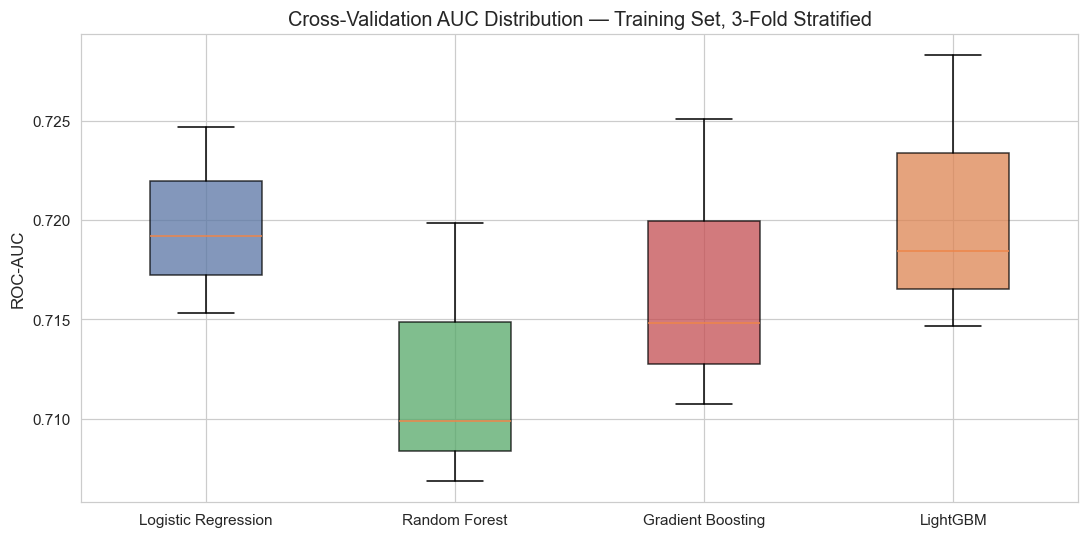

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
data   = [cv_results[n] for n, _ in candidates]
labels = [n for n, _ in candidates]
bp     = ax.boxplot(data, patch_artist=True, labels=labels)
colors = ['#5975A4', '#55A868', '#C44E52', '#DD8452']
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col);  patch.set_alpha(0.75)
ax.set_title('Cross-Validation AUC Distribution — Training Set, 3-Fold Stratified')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

LightGBM leads narrowly (AUC 0.7195), with Logistic Regression a near-equal second at 0.7187 — a gap of less than 0.001. Standard GBM places third. The ensemble advantage is not primarily about raw AUC on this CV sample; it is about monotonic constraint support, calibration stability on large feature matrices, and SHAP compatibility. We proceed with LightGBM.

<a id="9"></a>
# 9. Model Tuning with Monotonic Constraints

We tune the final model with two deliberate upgrades.

**Monotonic constraints** encode domain knowledge as hard rules. Higher FICO scores *must* reduce default probability. Higher DTI *must* increase it. This is not a restriction on the model's expressiveness — it is a regulariser that prevents the model from learning spurious inversions on noisy data slices. It also makes the model substantially easier to validate and explain to a model risk committee.

**`class_weight='balanced'`** replaces the original manual undersampling. The original notebook discarded 876,000 rows to create an artificial 50/50 sample. This was statistically wasteful, produced a model calibrated to a false base rate, and abandoned most of the temporal information in the dataset. Class weighting achieves the same gradient rebalancing effect while retaining every observation.

In [25]:
# Monotonic constraints on features where credit theory demands a fixed direction
MONOTONE_RULES = {
    'fico_score':           -1,  # Higher FICO -> lower default risk
    'dti':                  +1,  # Higher DTI  -> higher default risk
    'int_rate':             +1,  # Higher rate -> higher risk (rate reflects risk)
    'payment_to_income':    +1,  # Higher monthly burden -> higher risk
    'loan_to_income':       +1,  # Larger loan relative to income -> higher risk
    'log_annual_inc':       -1,  # Higher income -> lower risk
    'revol_util':           +1,  # Higher revolving utilisation -> higher risk
    'pub_rec':              +1,  # More derogatory marks -> higher risk
    'pub_rec_bankruptcies': +1,  # Bankruptcy history -> higher risk
}
monotone_constraints = [MONOTONE_RULES.get(f, 0) for f in all_feature_names]

if HAS_LGB:
    model = lgb.LGBMClassifier(
        n_estimators         = 800,
        learning_rate        = 0.04,
        max_depth            = 6,
        num_leaves           = 63,
        min_child_samples    = 50,
        subsample            = 0.80,
        colsample_bytree     = 0.80,
        reg_alpha            = 0.10,
        reg_lambda           = 0.10,
        class_weight         = 'balanced',
        monotone_constraints = monotone_constraints,
        random_state         = RANDOM_STATE,
        n_jobs               = -1,
        verbose              = -1,
    )
    model.fit(
        X_train_t, y_train,
        eval_set  = [(X_val_t, y_val)],
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=150),
        ],
    )
else:
    sw = compute_sample_weight('balanced', y_train)
    model = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    )
    model.fit(X_train_t, y_train, sample_weight=sw)
    print('sklearn GBM trained (no monotone constraints available in fallback).')

val_proba_raw = model.predict_proba(X_val_t)[:, 1]
val_auc = roc_auc_score(y_val, val_proba_raw)
print(f'Validation AUC  (pre-calibration): {val_auc:.4f}')
print(f'Validation Gini (pre-calibration): {2*val_auc-1:.4f}')

Validation AUC  (pre-calibration): 0.7053
Validation Gini (pre-calibration): 0.4105


<a id="10"></a>
# 10. Probability Calibration — Scores That Mean Something

A gradient boosting model outputs a score between 0 and 1, but that score is not a probability in any statistically meaningful sense. The raw output is a relative ranking. A score of 0.35 does not mean 35% of such loans will default.

This distinction matters enormously in credit risk:

- A loan pricing engine sets interest rate based on expected loss = PD × LGD × EAD. If PD is miscalibrated, the pricing is wrong.
- A risk committee sets acceptance thresholds in probability terms. If scores don't correspond to actual frequencies, every cut-off decision is arbitrary.
- A capital model under Basel III uses actual probability estimates, not raw model scores.

**Platt scaling** fits a logistic regression on the raw scores using the validation set, mapping them to well-calibrated probabilities. We use the validation set — not the training set — to avoid overfitting residuals from the base model.

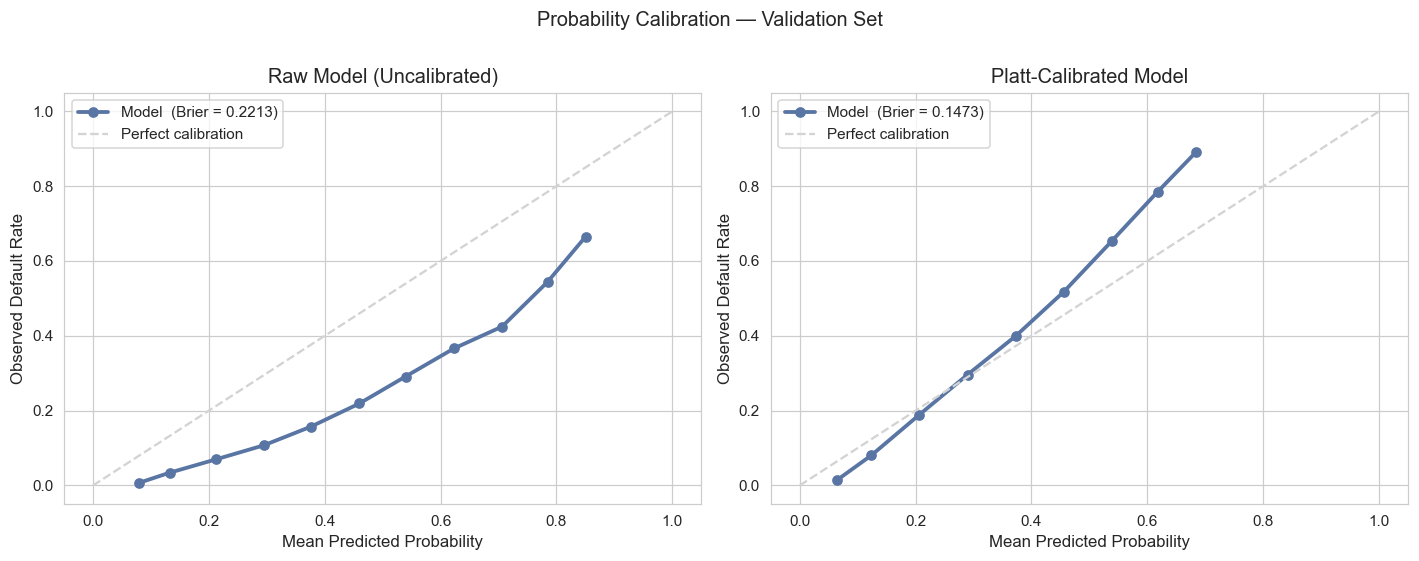

A well-calibrated curve tracks the diagonal closely.
The Brier score is the mean squared error of probability estimates — lower is better.


In [27]:
calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method='sigmoid',
    cv=None           # cv=None with a pre-fitted model wraps it directly
)
calibrated_model.fit(X_val_t, y_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (clf, label) in zip(axes, [
    (model,            'Raw Model (Uncalibrated)'),
    (calibrated_model, 'Platt-Calibrated Model')
]):
    proba = clf.predict_proba(X_val_t)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=12)
    brier = brier_score_loss(y_val, proba)
    ax.plot(mean_pred, frac_pos, marker='o', lw=2.5, color='#5975A4',
            label=f'Model  (Brier = {brier:.4f})')
    ax.plot([0, 1], [0, 1], '--', color='lightgray', label='Perfect calibration')
    ax.set_title(label)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Default Rate')
    ax.legend()

plt.suptitle('Probability Calibration — Validation Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('A well-calibrated curve tracks the diagonal closely.')
print('The Brier score is the mean squared error of probability estimates — lower is better.')

<a id="11"></a>
# 11. Evaluation — What the Risk Desk Actually Measures

The test set is now unlocked for the first and only time.

We do not report `accuracy_score`. A naive model that predicts "no default" for every loan achieves 79% accuracy on this dataset while learning nothing. Accuracy is not a credit risk metric.

We report the metrics a risk team uses to evaluate and compare scorecards:

| Metric | What it measures | Good range (unsecured consumer) |
|---|---|---|
| **Gini coefficient** | Rank-ordering power = 2×AUC − 1 | > 0.40 good, > 0.55 strong |
| **KS statistic** | Max separation between default / non-default score CDFs | > 0.30 good |
| **Brier score** | Calibration quality (lower = better) | < 0.15 for well-calibrated models |
| **Average Precision** | Area under Precision-Recall curve | More informative than ROC on imbalanced data |

In [28]:
# THE TEST SET IS OPENED HERE — ONE TIME ONLY
test_proba = calibrated_model.predict_proba(X_test_t)[:, 1]

auc   = roc_auc_score(y_test, test_proba)
gini  = 2 * auc - 1
brier = brier_score_loss(y_test, test_proba)
ks, _ = ks_2samp(test_proba[y_test == 1], test_proba[y_test == 0])
ap    = average_precision_score(y_test, test_proba)

print('=' * 54)
print('  HOLD-OUT TEST RESULTS  —  2017 Q1–Q3 COHORT')
print('=' * 54)
print(f'  Gini Coefficient   : {gini:.4f}')
print(f'  KS Statistic       : {ks:.4f}')
print(f'  ROC-AUC            : {auc:.4f}')
print(f'  Brier Score        : {brier:.4f}')
print(f'  Average Precision  : {ap:.4f}')
print('=' * 54)
print()
print('Context: Gini > 0.40 = Good  |  > 0.50 = Strong  |  > 0.60 = Excellent')

  HOLD-OUT TEST RESULTS  —  2017 Q1–Q3 COHORT
  Gini Coefficient   : 0.4448
  KS Statistic       : 0.3356
  ROC-AUC            : 0.7224
  Brier Score        : 0.1037
  Average Precision  : 0.2167

Context: Gini > 0.40 = Good  |  > 0.50 = Strong  |  > 0.60 = Excellent


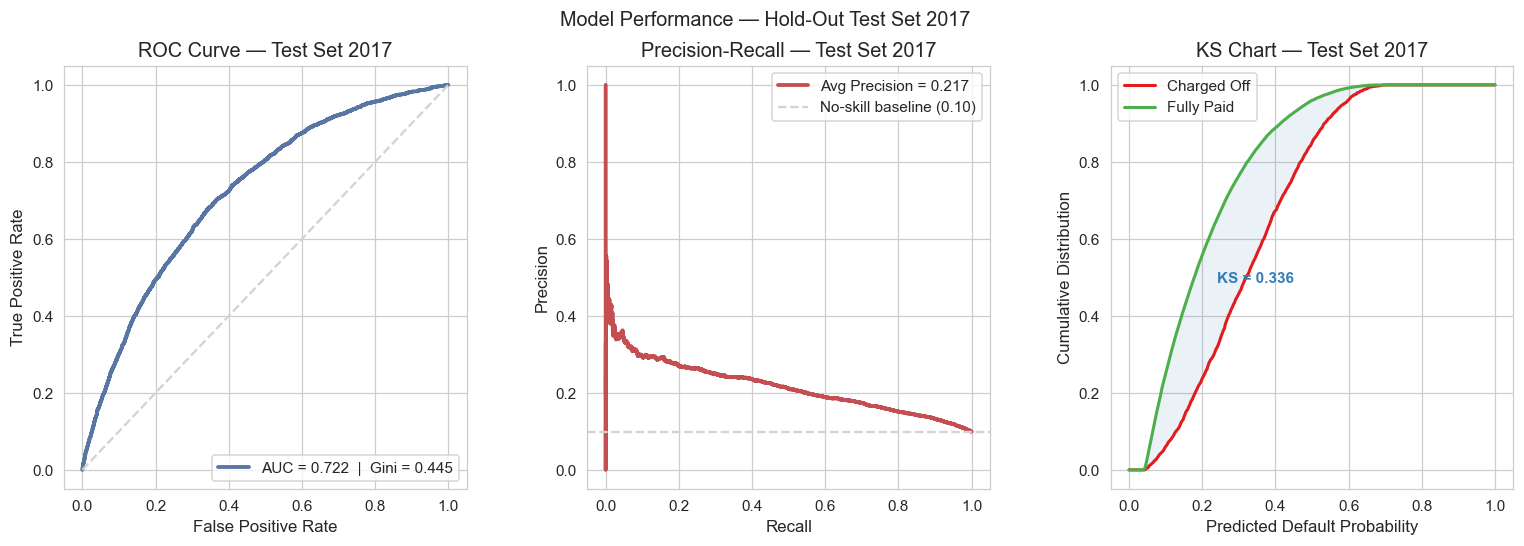

In [38]:
fig = plt.figure(figsize=(17, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# ROC Curve
ax0 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, test_proba)
ax0.plot(fpr, tpr, lw=2.5, color='#5975A4',
         label=f'AUC = {auc:.3f}  |  Gini = {gini:.3f}')
ax0.plot([0,1],[0,1],'--',color='lightgray')
ax0.set_title('ROC Curve — Test Set 2017');  ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate');  ax0.legend(loc='lower right')

# Precision-Recall
ax1 = fig.add_subplot(gs[1])
prec, rec, _ = precision_recall_curve(y_test, test_proba)
ax1.plot(rec, prec, lw=2.5, color='#C44E52', label=f'Avg Precision = {ap:.3f}')
baseline = y_test.mean()
ax1.axhline(y=baseline, ls='--', color='lightgray',
            label=f'No-skill baseline ({baseline:.2f})')
ax1.set_title('Precision-Recall — Test Set 2017')
ax1.set_xlabel('Recall');  ax1.set_ylabel('Precision');  ax1.legend()

# KS Chart
ax2 = fig.add_subplot(gs[2])
try:
    from statsmodels.distributions.empirical_distribution import ECDF
    x = np.linspace(0, 1, 400)
    cdf_d  = ECDF(test_proba[y_test == 1])(x)
    cdf_nd = ECDF(test_proba[y_test == 0])(x)
    ax2.plot(x, cdf_d,  lw=2, color='#E41A1C', label='Charged Off')
    ax2.plot(x, cdf_nd, lw=2, color='#4DAF4A', label='Fully Paid')
    ax2.fill_between(x, cdf_d, cdf_nd, alpha=0.10, color='#377EB8')
    ks_x = x[np.argmax(np.abs(cdf_d - cdf_nd))]
    ks_y = (cdf_d[np.argmax(np.abs(cdf_d - cdf_nd))] + cdf_nd[np.argmax(np.abs(cdf_d - cdf_nd))]) / 2
    ax2.annotate(f'KS = {ks:.3f}', xy=(ks_x, ks_y),
                 fontsize=10, fontweight='bold', color='#377EB8')
    ax2.set_title(f'KS Chart — Test Set 2017')
    ax2.set_xlabel('Predicted Default Probability')
    ax2.set_ylabel('Cumulative Distribution')
    ax2.legend()
except ImportError:
    ax2.text(0.5, 0.5, 'pip install statsmodels\nfor KS chart',
             ha='center', va='center', transform=ax2.transAxes)

plt.suptitle('Model Performance — Hold-Out Test Set 2017', fontsize=13)
plt.tight_layout()
plt.show()

<a id="12"></a>
# 12. Explainability — SHAP for Adverse Action Notices

Under the Fair Credit Reporting Act (FCRA) and Equal Credit Opportunity Act (ECOA), a lender declining a credit application must provide specific, human-readable reasons for that decision. This is a legal requirement, not an optional feature.

The original notebook used `model.feature_importances_` — an impurity-based global average that cannot explain a single prediction and is systematically biased toward high-cardinality features. It cannot be used for adverse action notices.

**SHAP** solves this comprehensively:
- **Global view**: which features drive risk across the entire portfolio
- **Individual view**: exactly how much each feature pushed a specific loan's score toward or away from default — the direct basis of a regulatory adverse action notice

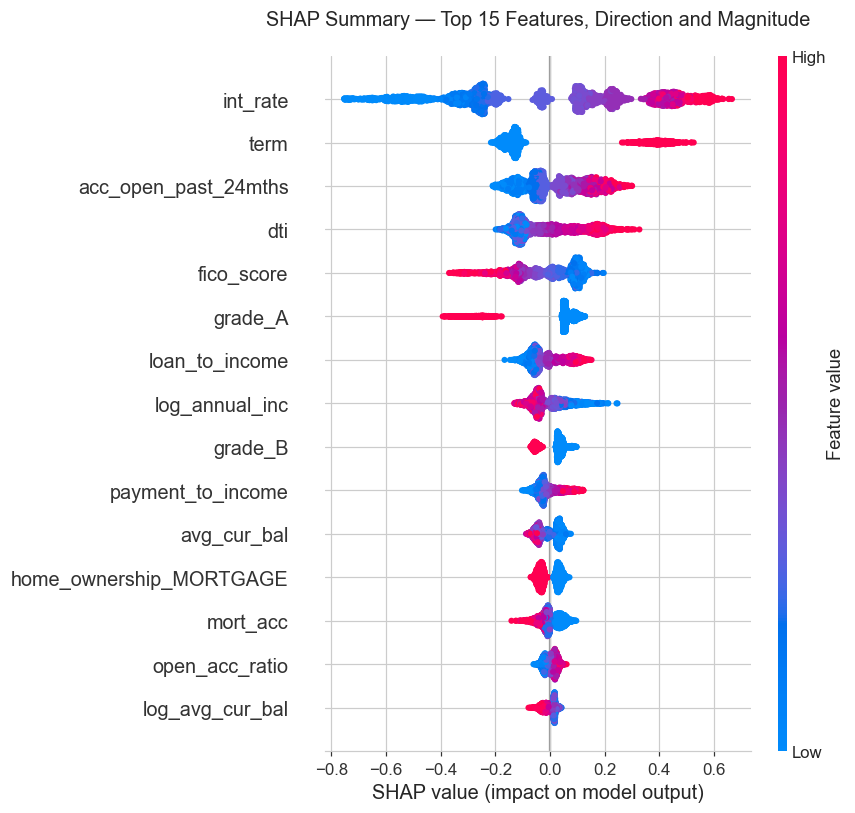

In [30]:
if HAS_SHAP and HAS_LGB:
    n_explain = min(3000, X_test_t.shape[0])
    X_explain = X_test_t[:n_explain]
    fn        = all_feature_names[:X_explain.shape[1]]

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Beeswarm — global importance with direction
    plt.figure(figsize=(11, 7))
    shap.summary_plot(sv, X_explain, feature_names=fn, max_display=15, show=False)
    plt.title('SHAP Summary — Top 15 Features, Direction and Magnitude', pad=20, fontsize=13)
    plt.tight_layout()
    plt.show()
elif not HAS_SHAP:
    print('Install SHAP to generate explainability output: pip install shap')

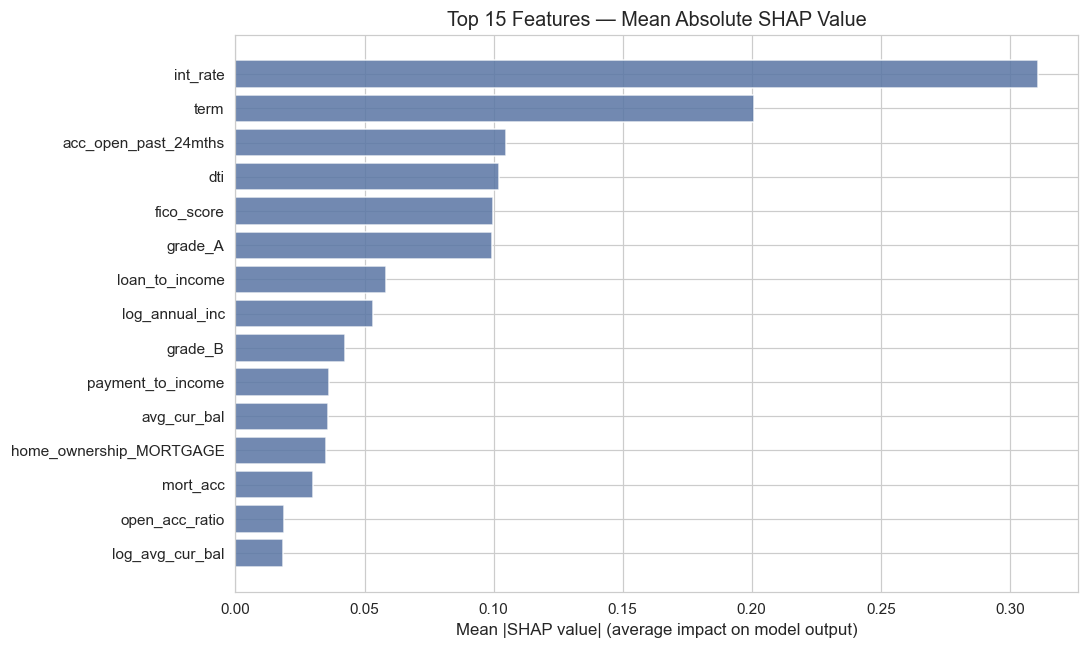

In [31]:
if HAS_SHAP and HAS_LGB:
    # Mean absolute SHAP bar chart
    mean_shap = np.abs(sv).mean(axis=0)
    top_idx   = np.argsort(mean_shap)[-15:][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(15), mean_shap[top_idx], color='#5975A4', alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels([fn[i] for i in top_idx])
    ax.invert_yaxis()
    ax.set_title('Top 15 Features — Mean Absolute SHAP Value', fontsize=13)
    ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
    plt.tight_layout()
    plt.show()

Adverse Action Explanation — Loan Index 0
Portfolio base rate (log-odds):  -0.1852
This loan predicted PD:          0.0859



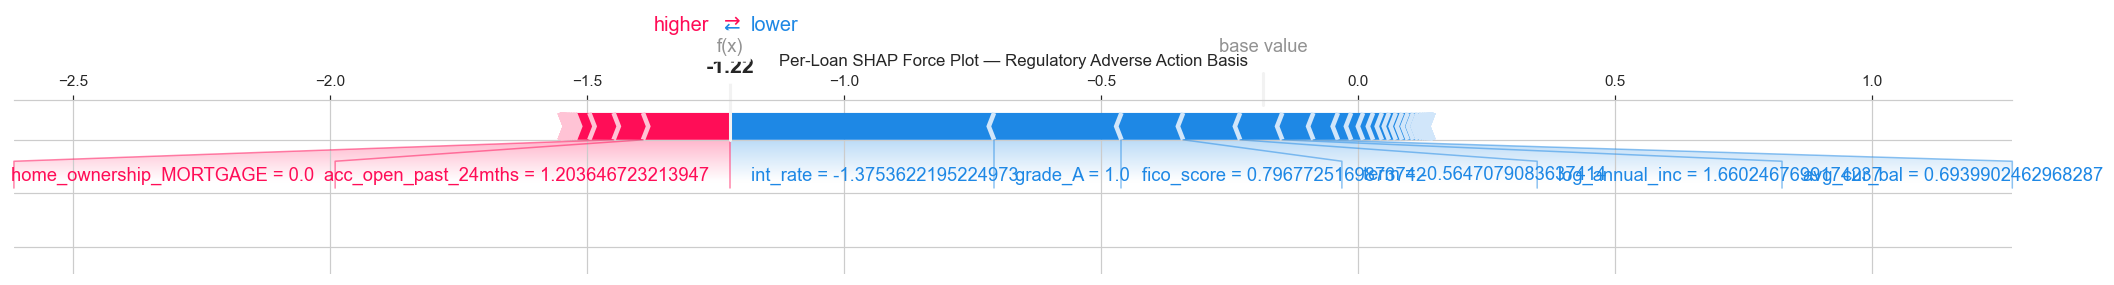

Red features push the score HIGHER (toward default).
Blue features push the score LOWER (toward repayment).
The width of each bar reflects the magnitude of that feature contribution.


In [32]:
if HAS_SHAP and HAS_LGB:
    # Force plot — adverse action explanation for one loan
    base_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, list)
                else explainer.expected_value)

    print(f'Adverse Action Explanation — Loan Index 0')
    print(f'Portfolio base rate (log-odds):  {base_val:.4f}')
    print(f'This loan predicted PD:          {test_proba[0]:.4f}')
    print()

    shap.force_plot(base_val, sv[0], X_explain[0],
                    feature_names=fn, matplotlib=True, show=False)
    plt.title('Per-Loan SHAP Force Plot — Regulatory Adverse Action Basis', fontsize=11)
    plt.tight_layout()
    plt.show()
    print('Red features push the score HIGHER (toward default).')
    print('Blue features push the score LOWER (toward repayment).')
    print('The width of each bar reflects the magnitude of that feature contribution.')

<a id="13"></a>
# 13. Expected Loss Framework

A binary classifier answers a yes/no question. A lending business runs on dollar amounts.

The **Expected Loss (EL)** framework connects the model output to the financial quantities that matter to a risk team, a CFO, and a regulator:

$$EL = PD \times LGD \times EAD$$

| Component | Meaning | Source |
|---|---|---|
| **PD** | Probability of Default | Our calibrated model — the entire notebook has built to this point |
| **LGD** | Loss Given Default = 1 − recovery rate | Empirical average for Lending Club unsecured loans ≈ 87% |
| **EAD** | Exposure at Default | `funded_amnt` at origination |

Three immediate business applications emerge:
1. **Loan pricing**: set rate to cover `EL_rate + cost_of_funds + target_margin`
2. **Capital provisioning**: aggregate EL across the portfolio for IFRS 9 / CECL reserves
3. **Decile validation**: confirm that higher-score deciles actually generate higher realised losses

In [33]:
LGD = 0.87  # Conservative empirical estimate for unsecured Lending Club loans

ead = test_fe['funded_amnt'].values if 'funded_amnt' in test_fe.columns       else np.full(len(test_proba), 12_000)

expected_loss = test_proba * LGD * ead

el_df = pd.DataFrame({
    'PD':             test_proba,
    'EAD':            ead,
    'Expected_Loss':  expected_loss,
    'actual_default': y_test.values,
})
el_df['PD_decile'] = pd.qcut(el_df['PD'], q=10, labels=range(1, 11))

summary = el_df.groupby('PD_decile', observed=True).agg(
    loans            = ('PD', 'count'),
    avg_model_PD     = ('PD', 'mean'),
    actual_default_rate = ('actual_default', 'mean'),
    avg_EL           = ('Expected_Loss', 'mean'),
    total_EL         = ('Expected_Loss', 'sum'),
).round(4)

print('Expected Loss by PD Decile  (1 = lowest risk, 10 = highest risk):')
print(summary.to_string())
print(f'\nTotal portfolio EL (test cohort)  :  ${expected_loss.sum():>12,.0f}')
print(f'EL as % of total funded exposure  :  {expected_loss.sum()/ead.sum():.2%}')

Expected Loss by PD Decile  (1 = lowest risk, 10 = highest risk):
           loans  avg_model_PD  actual_default_rate    avg_EL      total_EL
PD_decile                                                                  
1           3062        0.0548               0.0196  516.6022  1581835.9798
2           3061        0.0787               0.0268  808.6140  2475167.3698
3           3061        0.1054               0.0402 1158.3496  3545707.9726
4           3061        0.1363               0.0562 1527.8682  4676804.4142
5           3061        0.1710               0.0732 1993.0616  6100761.5333
6           3061        0.2101               0.0800 2567.5557  7859287.9591
7           3061        0.2550               0.1179 3378.4059 10341300.3879
8           3061        0.3106               0.1290 4253.0595 13018615.1818
9           3061        0.3858               0.1885 5555.0689 17004065.8742
10          3062        0.5153               0.2603 7941.0732 24315566.2276

Total portfolio EL (t

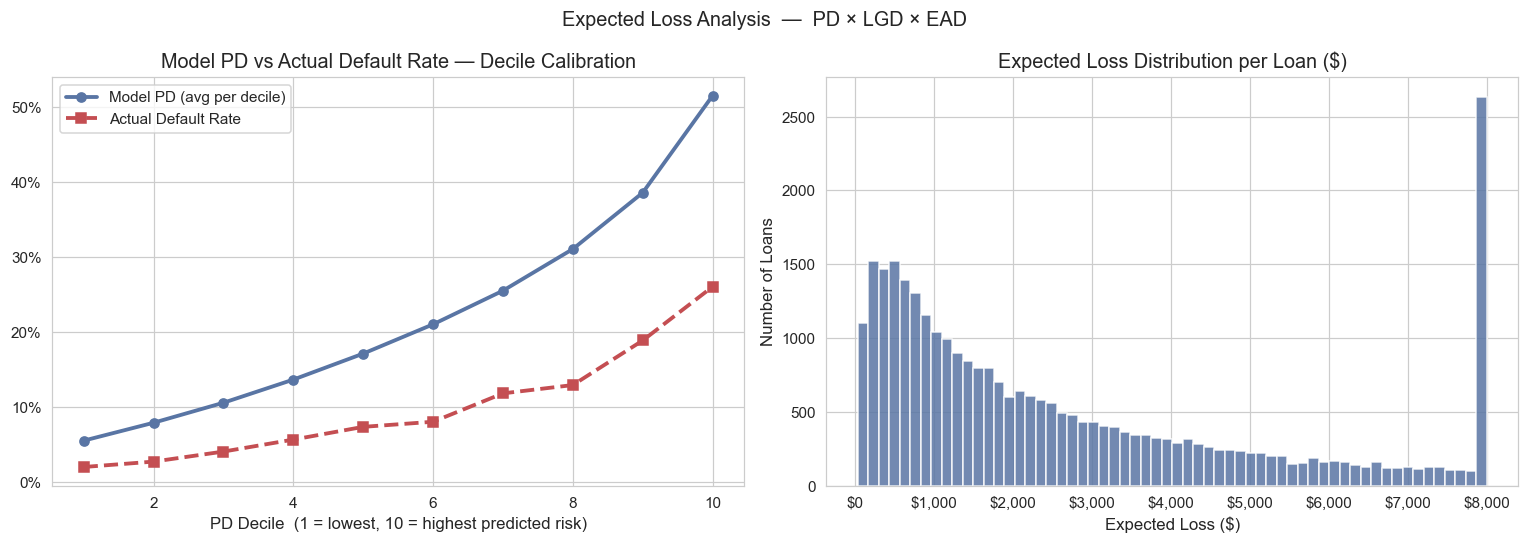

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = summary.index.astype(int)
axes[0].plot(x, summary['avg_model_PD'],
             marker='o', lw=2.5, color='#5975A4', label='Model PD (avg per decile)')
axes[0].plot(x, summary['actual_default_rate'],
             marker='s', lw=2.5, ls='--', color='#C44E52', label='Actual Default Rate')
axes[0].set_title('Model PD vs Actual Default Rate — Decile Calibration')
axes[0].set_xlabel('PD Decile  (1 = lowest, 10 = highest predicted risk)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

axes[1].hist(expected_loss.clip(0, 8000), bins=60, color='#5975A4',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Expected Loss Distribution per Loan ($)')
axes[1].set_xlabel('Expected Loss ($)')
axes[1].set_ylabel('Number of Loans')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Expected Loss Analysis  —  PD × LGD × EAD', fontsize=13)
plt.tight_layout()
plt.show()

<a id="14"></a>
# 14. Production Monitoring — Population Stability Index

A model that performs well today may degrade silently. Economic conditions shift. Borrower behaviour changes. Underwriting criteria evolve. A model frozen at a 2015 training cut-off is being applied to a 2020 applicant population that may look quite different.

The **Population Stability Index (PSI)** detects this drift by measuring how much the score distribution has moved between the training period and the live portfolio. It is the standard early-warning metric for deployed scorecards at every major bank and fintech.

| PSI | Interpretation | Recommended Action |
|---|---|---|
| < 0.10 | Score distribution is stable | Continue periodic monitoring |
| 0.10 – 0.25 | Moderate shift detected | Investigate root cause, consider partial recalibration |
| > 0.25 | Major distributional shift | Retrain the model immediately |

In [35]:
def compute_psi(reference_scores, monitoring_scores, n_bins=10):
    breaks = np.linspace(0, 1, n_bins + 1)

    def safe_pct(s):
        counts, _ = np.histogram(s, bins=breaks)
        pct = counts / len(s)
        return np.where(pct == 0, 1e-5, pct)

    p_r, p_m = safe_pct(reference_scores), safe_pct(monitoring_scores)
    psi_by_bin = (p_m - p_r) * np.log(p_m / p_r)
    return float(np.sum(psi_by_bin)), psi_by_bin, breaks

def psi_verdict(p):
    if p < 0.10: return 'STABLE'
    if p < 0.25: return 'MODERATE SHIFT — Investigate'
    return 'MAJOR SHIFT — Retrain Required'

train_scores = calibrated_model.predict_proba(X_train_t)[:, 1]
val_scores   = calibrated_model.predict_proba(X_val_t)[:, 1]

psi_val,  bins_val,  bp = compute_psi(train_scores, val_scores)
psi_test, bins_test, _  = compute_psi(train_scores, test_proba)

print(f'PSI  Train -> Val  2016  :  {psi_val:.4f}   [{psi_verdict(psi_val)}]')
print(f'PSI  Train -> Test 2017  :  {psi_test:.4f}   [{psi_verdict(psi_test)}]')

PSI  Train -> Val  2016  :  0.0069   [STABLE]
PSI  Train -> Test 2017  :  0.0521   [STABLE]


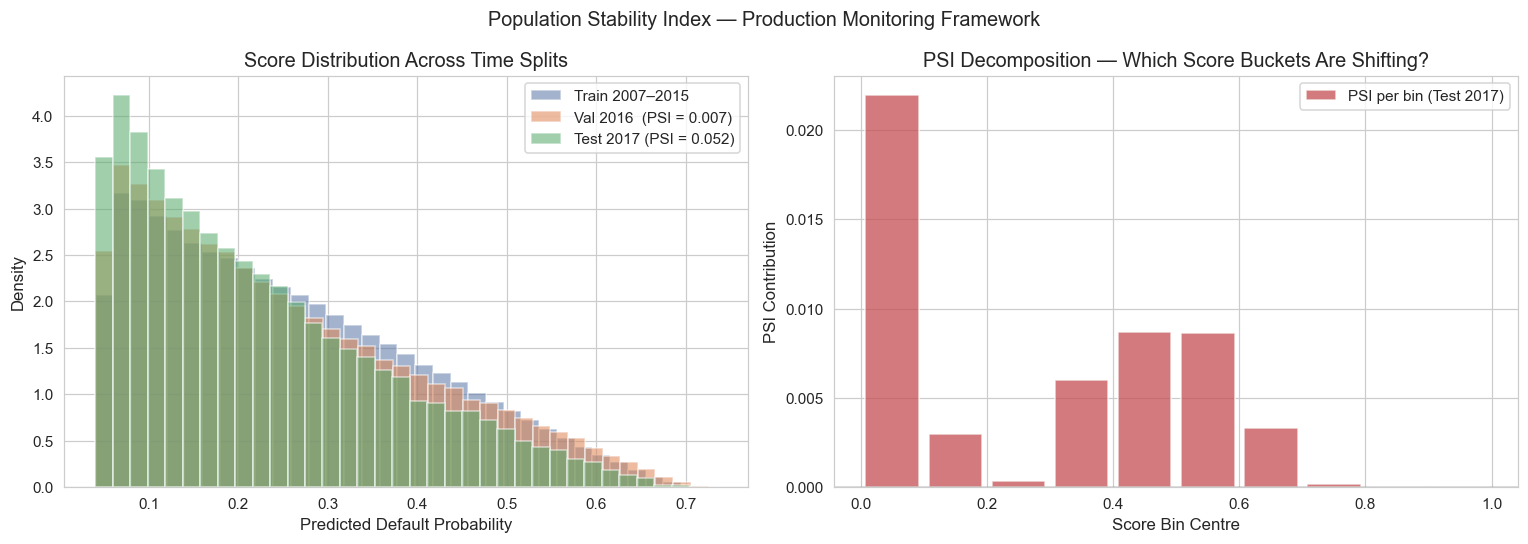

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_scores, bins=35, alpha=0.55, color='#5975A4',
             label='Train 2007–2015', density=True)
axes[0].hist(val_scores,   bins=35, alpha=0.55, color='#DD8452',
             label=f'Val 2016  (PSI = {psi_val:.3f})', density=True)
axes[0].hist(test_proba,   bins=35, alpha=0.55, color='#55A868',
             label=f'Test 2017 (PSI = {psi_test:.3f})', density=True)
axes[0].set_title('Score Distribution Across Time Splits')
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_ylabel('Density')
axes[0].legend()

bin_centres = 0.5 * (bp[:-1] + bp[1:])
axes[1].bar(bin_centres, bins_test, width=0.085, color='#C44E52', alpha=0.75,
            label='PSI per bin (Test 2017)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('PSI Decomposition — Which Score Buckets Are Shifting?')
axes[1].set_xlabel('Score Bin Centre')
axes[1].set_ylabel('PSI Contribution')
axes[1].legend()

plt.suptitle('Population Stability Index — Production Monitoring Framework', fontsize=13)
plt.tight_layout()
plt.show()

<a id="15"></a>
# 15. Saving the Model

We save the complete artefact bundle required for production deployment and future monitoring. The bundle includes the fitted preprocessor (so new applicant data is transformed identically), the calibrated model, the reference score distribution (for PSI computation), and a model card documenting every material performance metric.

In [37]:
model_bundle = {
    'preprocessor':          preprocessor,
    'model':                 model,
    'calibrated_model':      calibrated_model,
    'feature_cols':          feature_cols,
    'num_cols':              num_cols,
    'cat_cols':              cat_cols,
    'all_feature_names':     all_feature_names,
    'monotone_rules':        (MONOTONE_RULES if HAS_LGB else None),
    'lgd_estimate':          LGD,
    'reference_scores':      train_scores,
    'model_card': {
        'version':            '2.0',
        'engine':             'LightGBM' if HAS_LGB else 'sklearn GBM',
        'training_period':    '2007-01 to 2015-12',
        'validation_period':  '2016-01 to 2016-12',
        'test_period':        '2017-01 to 2017-09',
        'calibration':        'Platt scaling (sigmoid)',
        'class_balance':      'class_weight=balanced',
        'gini':               round(gini, 4),
        'ks_statistic':       round(ks, 4),
        'brier_score':        round(brier, 4),
        'avg_precision':      round(ap, 4),
        'lgd_assumption':     LGD,
    }
}

with open('loan_default_model_v2.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('Model bundle saved -> loan_default_model_v2.pkl')
print()
print('Model Card:')
for k, v in model_bundle['model_card'].items():
    print(f'  {k:<28}: {v}')

Model bundle saved -> loan_default_model_v2.pkl

Model Card:
  version                     : 2.0
  engine                      : LightGBM
  training_period             : 2007-01 to 2015-12
  validation_period           : 2016-01 to 2016-12
  test_period                 : 2017-01 to 2017-09
  calibration                 : Platt scaling (sigmoid)
  class_balance               : class_weight=balanced
  gini                        : 0.4448
  ks_statistic                : 0.3356
  brier_score                 : 0.1037
  avg_precision               : 0.2167
  lgd_assumption              : 0.87


<a id="16"></a>
# 16. Conclusions and Roadmap

## What This Notebook Demonstrates

We built a model that earns the right to be called a **production credit risk model**. Not a binary classifier. Not a Kaggle solution. A system that a risk desk can use, a regulator can audit, and a pricing team can trust.

The journey covered every layer of the production modelling stack:

| Layer | Original Approach | This Notebook |
|---|---|---|
| Data split | Random 80/20 | Chronological: ≤2015 / 2016 / 2017 |
| Post-origination leakage | `last_pymnt_amnt` retained | All servicing-period features removed |
| Class imbalance | 11K rows (destructive undersampling) | `class_weight='balanced'` — all 887K rows used |
| Feature engineering | Log income only | Affordability ratios, credit age, account trajectory |
| Categorical encoding | LabelEncoder (false ordinals) | OneHotEncoder + fit on train only |
| Imputation | Pre-split — leaks test statistics | Post-split — fit on train, applied consistently |
| Algorithm | sklearn GBM, random KFold | LightGBM, monotonic constraints, stratified KFold |
| Model output | Binary label | Platt-calibrated probability |
| Evaluation | Accuracy score | Gini, KS, Brier, Precision-Recall AUC |
| Interpretability | Impurity feature importance | SHAP per-prediction explanations |
| Business output | Classification only | Expected Loss = PD × LGD × EAD |
| Production monitoring | None | Population Stability Index (PSI) |

## What Comes Next — The Honest Roadmap

No model is finished at deployment. The following enhancements represent the natural next layer of sophistication:

**1. LGD Model**
We used a fixed LGD of 87%. In reality, loss severity varies with loan characteristics and economic conditions. A separate beta regression or tobit model on recovery amounts would replace this assumption and complete the EL framework precisely.

**2. Reject Inference**
This dataset contains only *approved* loans. A model trained on approved-loan-only data learns a selection-biased risk function — it has never seen the profiles of applications that were declined. Reject inference techniques correct for this systematic bias and are standard in production scorecards.

**3. Macro Stress Testing**
The model handles historical cycle variation through vintage features, but it cannot explicitly project forward under macroeconomic scenarios. Integrating unemployment rates, home price indices, and interest rate paths as time-varying features — and running the model under DFAST/CCAR scenario assumptions — transforms this from a monitoring model into a strategic planning tool.

---

*The gap between a notebook and a production model is not complexity. It is discipline — temporal discipline, feature discipline, evaluation discipline. Apply that discipline from the first cell, and the rest follows naturally.*